# Laptop Price Category Prediction - Classification Track (Algorithms 1-5)

## Scope of this notebook

This notebook covers the five classification algorithms for the capstone:

1. **Logistic Regression**
2. **K-Nearest Neighbors**
3. **Gaussian Naive Bayes**
4. **Decision Tree Classifier**
5. **Support Vector Classifier (SVC)**

The data used here is `classification.csv`, produced by the pre_preprocessing notebook. It contains the same cleaned and encoded laptop specs as the other tracks (company, laptop type, OS, RAM, weight, screen size, storage, resolution, PPI, IPS/touchscreen flags, SSD/HDD flags), but instead of the raw `price`, the target column is `price_category` - laptops binned into four quartile-based groups: Budget, Mid-range, Premium, and Flagship. `price` itself was dropped when this file was built, since keeping it alongside a category derived directly from it would let the model see the answer.


In [ ]:
from google.colab import files
upload = files.upload()

Saving classification.csv to classification.csv


## 1. Load classification.csv

`classification.csv` is read in and `head()` is checked just to confirm the columns loaded correctly - one-hot encoded company/type/OS columns, the numeric spec columns, the boolean flags, and `price_category` as the last column.


In [ ]:
# Load the dataset

import pandas as pd
df = pd.read_csv('classification.csv')
df.head()

,inches,ram,weight,is_ips,is_touchscreen,res_width,res_height,storage_gb,has_ssd,has_hdd,...,typename_Workstation,opsys_Chrome Os,opsys_Linux,opsys_Mac Os X,opsys_Macos,opsys_No Os,opsys_Windows 10,opsys_Windows 10 S,opsys_Windows 7,price_category
0,13.3,8.0,1.37,1,0,2560,1600,128.0,1,0,...,False,False,False,False,True,False,False,False,False,Premium
1,13.3,8.0,1.34,0,0,1440,900,128.0,0,0,...,False,False,False,False,True,False,False,False,False,Mid-range
2,15.6,8.0,1.86,0,0,1920,1080,256.0,1,0,...,False,False,False,False,False,True,False,False,False,Budget
3,15.4,16.0,1.83,1,0,2880,1800,512.0,1,0,...,False,False,False,False,True,False,False,False,False,Flagship
4,13.3,8.0,1.37,1,0,2560,1600,256.0,1,0,...,False,False,False,False,True,False,False,False,False,Flagship


## 2. Split into features and target

`price_category` is pulled out as `y` and everything else becomes `X`. The value counts show how the four price bands are distributed across the dataset - since `price_category` was built from quartiles of price, the four classes should be close to equal in size to begin with, but the exact counts are worth checking since the cleaning steps upstream (dropping missing rows, removing duplicates) could have shifted the balance slightly.


In [ ]:
# Separate features and target

X = df.drop('price_category', axis=1)
y = df['price_category']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())

Features shape: (1243, 42)
Target shape: (1243,)

Class distribution:
price_category
Mid-range    312
Budget       311
Flagship     311
Premium      309
Name: count, dtype: int64


## 3. Class distribution plot

Plotting the counts as a bar chart just makes the balance (or imbalance) easier to see at a glance than reading numbers off a printout. If the bars come out roughly the same height, that's a sign the quartile-based binning did its job.


price_category
Mid-range    312
Budget       311
Flagship     311
Premium      309
Name: count, dtype: int64


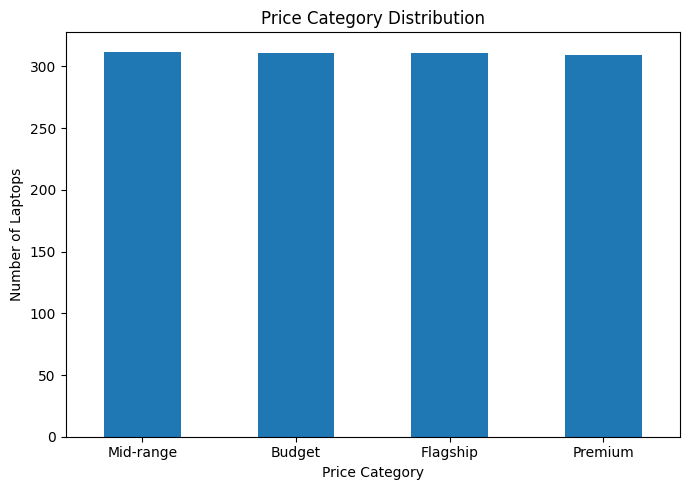

In [ ]:
# Check Target distribution

import matplotlib.pyplot as plt

print(y.value_counts())

plt.figure(figsize=(7, 5))
y.value_counts().plot(kind='bar')

plt.title('Price Category Distribution')
plt.xlabel('Price Category')
plt.ylabel('Number of Laptops')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

A few things worth noting from this chart when writing it up: which category has the most/fewest laptops, and how big the gap is between the largest and smallest bar. Even a small imbalance is the reason accuracy alone isn't reported later - weighted F1 is used alongside it so a class with slightly fewer samples doesn't get ignored in the scoring.


## 4. Train/test split

An 80:20 split, stratified on `y` so all four price categories show up in roughly the same proportion in both the training and test sets. Since `price_category` is already a discrete label, stratifying is straightforward here.


In [ ]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (994, 42)
Testing set: (249, 42)


## 5. Scaling

`StandardScaler` is fit only on the training data and then applied to both train and test, so nothing from the test set leaks into the scaling statistics.

Logistic Regression, KNN, and SVC all use the scaled versions below, since they're either distance-based or rely on gradient optimisation that behaves badly when features like `ram` and `res_width` sit on very different numeric scales. The Decision Tree later in the notebook is fit on the unscaled data instead - it splits on thresholds per feature, so scaling makes no difference to how it partitions the data.


In [ ]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


# 1) Logistic Regression

Logistic Regression is used here as the baseline model. It fits a linear decision boundary between the four price categories on the standardised features and converts that into class probabilities. `max_iter` is bumped up to 1000 so the solver has enough room to converge given the number of encoded features.


In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression completed.")

Logistic Regression completed.


# 2) K-Nearest Neighbors

KNN predicts a laptop's price category by looking at its closest neighbours in the scaled feature space and taking a majority vote. `GridSearchCV` is used to pick the best `n_neighbors` from `[3, 5, 7, 9, 11, 13, 15]`, using 5-fold CV scored on weighted F1 rather than accuracy, again to keep the class imbalance in mind while tuning.


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15]
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid,
    cv=5,
    scoring='f1_weighted'
)

knn_grid.fit(X_train_scaled, y_train)

print("Best K:", knn_grid.best_params_)

Best K: {'n_neighbors': 5}


In [ ]:
# best KNN model

knn_model = knn_grid.best_estimator_

y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN completed.")

KNN completed.


A small `k` lets the boundary follow local structure closely but can be thrown off by individual noisy points near the border between two price bands. A larger `k` smooths things out but risks blending together laptops from neighbouring categories (say, Mid-range and Premium) that are genuinely close in spec but priced differently. Whatever value the grid search picks reflects where that trade-off worked best on the training folds.


# 3) Gaussian Naive Bayes

Naive Bayes assumes each feature is independent given the price category and models each one as a Gaussian within that category. There's no hyperparameter search for this one - it's fit directly, which also makes it by far the quickest model to train.

The independence assumption is a stretch for this dataset though - features like `ram`, `storage_gb`, and `res_width` tend to move together (higher-spec laptops are higher-spec across the board), so this is really here as a simple, fast baseline rather than a model expected to lead the comparison.


In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)

print("Gaussian Naive Bayes completed.")

Gaussian Naive Bayes completed.


# 4) Decision Tree Classifier

The tree splits on individual feature thresholds (e.g. `ram <= 8`), which is why it's trained on the unscaled `X_train`/`X_test` rather than the scaled versions used above. `GridSearchCV` searches `max_depth` over `[2, 3, 4, 5, 6, 8, 10, None]` with 5-fold CV on weighted F1 - depth is capped this way because an unrestricted tree (`max_depth=None`) will keep splitting until it fits the training data almost perfectly, which usually means it's memorising noise rather than learning anything that generalises.


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 8, 10, None]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='f1_weighted'
)

dt_grid.fit(X_train, y_train)

print("Best Decision Tree parameters:", dt_grid.best_params_)

Best Decision Tree parameters: {'max_depth': 6}


In [ ]:
# best decision tree

dt_model = dt_grid.best_estimator_

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree completed.")

Decision Tree completed.


If the search settles on a shallow tree, that suggests a handful of features (probably RAM, storage, and screen specs) do most of the work separating the four price bands. A deeper tree picked by the search would mean the categories overlap more and need extra splits/interactions to pull apart cleanly.


# 5) Support Vector Classifier - SVC

SVC looks for the boundary that separates the price categories with the widest margin, using the scaled features since the margin calculation is distance-based. The grid search tunes two things together:

- `C` in `[0.1, 1, 10, 100]` - how much the model is penalised for training points that fall on the wrong side of the margin; small `C` favours a wider, more forgiving margin, large `C` fits the training points more tightly.
- `kernel` in `['linear', 'rbf', 'poly']` - whether the boundary is a straight hyperplane or allowed to curve.

Both are searched jointly with 5-fold CV, scored on weighted F1.


In [ ]:
from sklearn.svm import SVC

svc_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly']
}

svc_grid = GridSearchCV(
    SVC(random_state=42),
    svc_param_grid,
    cv=5,
    scoring='f1_weighted'
)

svc_grid.fit(X_train_scaled, y_train)

print("Best SVC parameters:", svc_grid.best_params_)

Best SVC parameters: {'C': 10, 'kernel': 'rbf'}


In [ ]:
# Best SVC

svc_model = svc_grid.best_estimator_

y_pred_svc = svc_model.predict(X_test_scaled)

print("SVC completed.")

SVC completed.


# Evaluation Metrics

All five models are now scored on the same held-out test set so they can be compared fairly.


## Evaluation function

One helper function scores every model the same way, using two metrics:

- **Accuracy** - the straightforward fraction of laptops assigned to the correct price band. Easy to read, but a model could get a decent accuracy just by leaning on whichever category is slightly more common.
- **Weighted F1** - precision and recall combined per class, then averaged and weighted by how many laptops are actually in each class. This is reported alongside accuracy so a model that's quietly bad at one of the smaller categories doesn't get a free pass.


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate_model(model_name, y_test, y_pred):

    accuracy = accuracy_score(y_test, y_pred)

    weighted_f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    return {
        'Algorithm': model_name,
        'Accuracy': accuracy,
        'Weighted F1': weighted_f1
    }

In [ ]:
results = []

results.append(
    evaluate_model(
        'Logistic Regression',
        y_test,
        y_pred_logistic
    )
)

results.append(
    evaluate_model(
        'KNN',
        y_test,
        y_pred_knn
    )
)

results.append(
    evaluate_model(
        'Gaussian Naive Bayes',
        y_test,
        y_pred_nb
    )
)

results.append(
    evaluate_model(
        'Decision Tree',
        y_test,
        y_pred_dt
    )
)

results.append(
    evaluate_model(
        'SVC',
        y_test,
        y_pred_svc
    )
)

## 1) Comparison table - Accuracy & Weighted F1 score

Results for all five classifiers, sorted by accuracy, with weighted F1 next to it.


In [ ]:
comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by='Accuracy',
    ascending=False
).reset_index(drop=True)

comparison_df['Accuracy'] = comparison_df['Accuracy'].round(4)
comparison_df['Weighted F1'] = comparison_df['Weighted F1'].round(4)

comparison_df

,Algorithm,Accuracy,Weighted F1
0,SVC,0.6908,0.6861
1,Logistic Regression,0.6506,0.6440
2,Decision Tree,0.6386,0.6155
3,KNN,0.6305,0.6249
4,Gaussian Naive Bayes,0.3936,0.3216


SVC performs the best, with the highest Accuracy (69.08%) and Weighted F1-score (68.61%). Gaussian Naive Bayes performs the weakest, while Logistic Regression, Decision Tree, and KNN show moderate performance.

The gap between SVC and Naive Bayes lines up with what was expected going in - SVC can bend its decision boundary through the kernel, while Naive Bayes is stuck with an independence assumption that doesn't really hold for these features.


## 2) Confusion matrices

Accuracy and F1 don't say which categories a model mixes up - a confusion matrix is plotted for each model so it's clear whether the mistakes are, say, Mid-range laptops getting called Premium, or something messier.


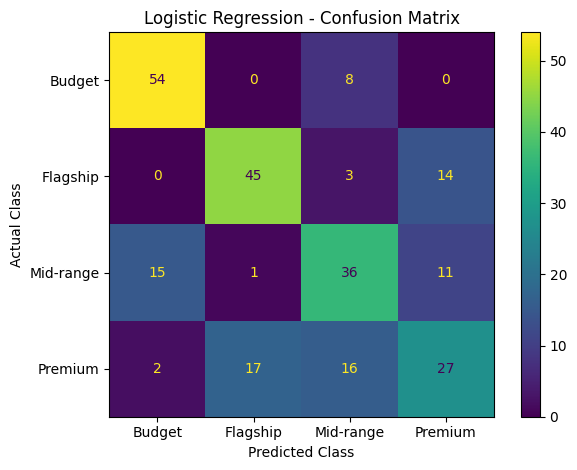

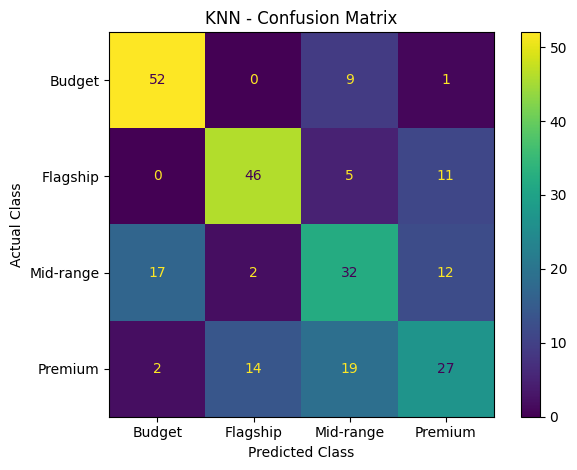

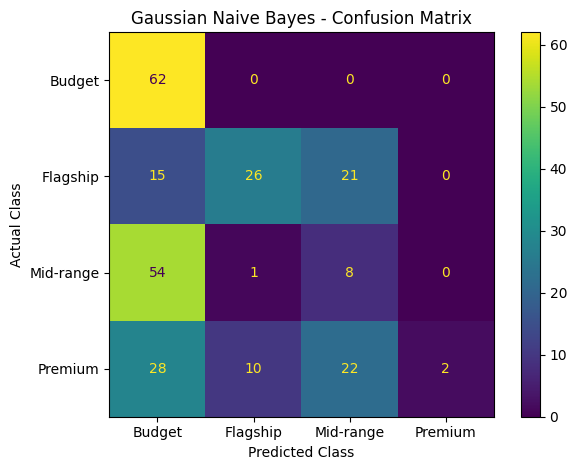

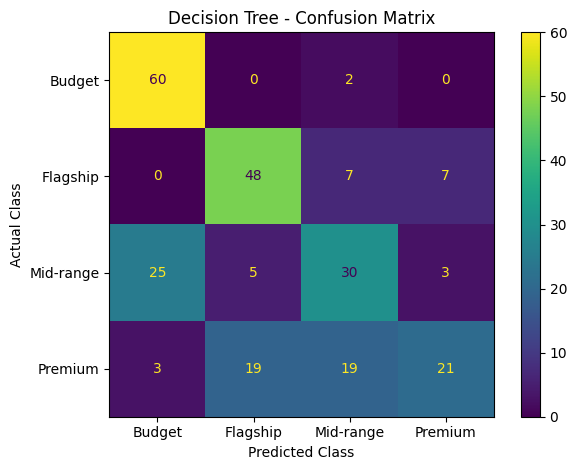

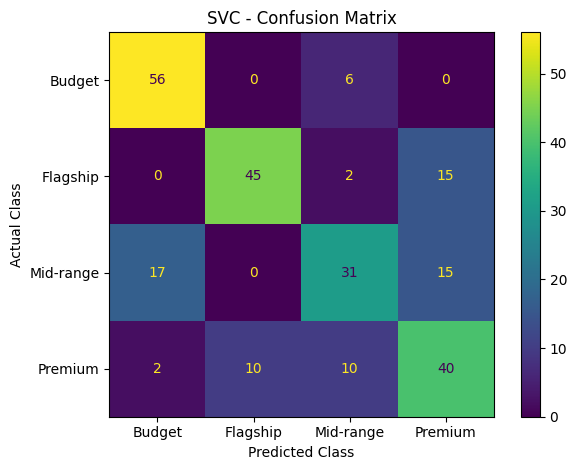

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

models_predictions = {
    'Logistic Regression': (logistic_model, y_pred_logistic),
    'KNN': (knn_model, y_pred_knn),
    'Gaussian Naive Bayes': (nb_model, y_pred_nb),
    'Decision Tree': (dt_model, y_pred_dt),
    'SVC': (svc_model, y_pred_svc)
}

for name, (model, predictions) in models_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=model.classes_
    )

    disp.plot()

    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted Class')
    plt.ylabel('Actual Class')
    plt.tight_layout()
    plt.show()

SVC shows the strongest overall classification, with 56 Budget, 45 Flagship, 31 Mid-range, and 40 Premium samples correctly classified. However, some confusion exists mainly between Flagship/Premium and Mid-range/Premium classes.

That pattern makes sense given how `price_category` was built - the boundaries between adjacent quartiles are just laptops sitting close together in price, so it's the neighbouring bands (Mid-range vs Premium, Premium vs Flagship) that get mixed up, not categories on opposite ends like Budget and Flagship.
